In [1]:
from typing import Literal
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud

from inference.persona_registry import PersonaRegistry

plt.rcParams["font.family"] = "Roboto"

# Helpers

In [2]:
TEXT_WIDTH = 418.25372 / 72.27  # 418... is the width in dots of the latex paper; latex uses 72.27 dots per inch

FULL_WIDTH = TEXT_WIDTH     # physical paper width
MEDIUM_WIDTH = FULL_WIDTH * 0.8
HALF_WIDTH = TEXT_WIDTH * 0.5
PLOT_HEIGHT = 4

sns.set_theme(
    style="whitegrid",
    context="paper",
    font_scale=1.0,
    rc={
        "axes.spines.top": False,
        "axes.spines.right": False,

        "axes.linewidth": 1.4,
        "axes.edgecolor": "0.4",

        "xtick.color": "0.4",
        "ytick.color": "0.4",
        "xtick.major.width": 1.4,
        "ytick.major.width": 1.4,
        "xtick.major.size": 4,
        "ytick.major.size": 4,

        "axes.labelweight": "medium",
        "axes.titlelocation": "left",
        "axes.titleweight": "bold",
        "figure.titleweight": "bold",

        "font.size": 9,
        "axes.labelsize": 10,
        "axes.titlesize": 12,
        "xtick.labelsize": 9,
        "ytick.labelsize": 9,
        "legend.fontsize": 10,
        "legend.title_fontsize": 11,
        "figure.titlesize": 14
    }
)

In [3]:
model_names = {
    "qwen3-0-6b": "Qwen3 0.6B",
    "qwen3-4b": "Qwen3 4B",
    "llama-3-2-1b-instruct": "Llama 3.2 1B",
    "llama-3-2-3b-instruct": "Llama 3.2 3B",
    "gemma-3-1b-it": "Gemma 3 1B",
    "gemma-3-4b-it": "Gemma 3 4B",
    "gpt-4-1-nano": "GPT-4.1 nano",
    "gpt-5-nano": "GPT-5 nano",
}

model_order = list(model_names.values())

dataset_names = {
    "mmlu-pro": "MMLU-Pro",
    "alpaca": "Alpaca",
    "MATH": "MATH",
    "ifbench": "IFBench",
    "flores": "FLORES+"
}

In [4]:
dfs = []
for file in Path("data/evaluation/").iterdir():
    dataset_name = file.stem
    if file.suffix != ".csv":
        continue
    raw_df = pd.read_csv(file, index_col=0)
    raw_df = raw_df.rename(columns={"iso_639_3": "category", "subject": "category"})

    raw_df.insert(0, "dataset", dataset_name)
    if "flores" in dataset_name or "alpaca" in dataset_name:
        raw_df = raw_df[raw_df["score"] != 1]
        raw_df.loc[raw_df["score"] == 2, "score"] -= 1
    dfs.append(raw_df)
df: pd.DataFrame = pd.concat(dfs, ignore_index=True)
df["model"] = df["model"].replace(model_names)
df["dataset"] = df["dataset"].replace(dataset_names)
df = df.rename(columns={"model": "Model", "score": "Score"})

In [5]:
persona_registry = PersonaRegistry()
persona_names = persona_registry.get_names()
persona_names = [p.replace("_persona", "") for p in persona_names]

plot_path = Path("plots/discussion")

# Word Cloud

In [6]:
model_dir = Path("data/inference")
for persona in ["beginner_teacher_persona", "intermediate_teacher_persona", "expert_teacher_persona"]:

    persona_strings = ""
    for model_path in model_dir.iterdir():
        for dataset_file in model_path.iterdir():
            if dataset_file.suffix != ".parquet":
                continue
            wc_df = pd.read_parquet(dataset_file)
            persona_col = wc_df[persona]
            persona_col = persona_col.dropna()
            persona_strings += " ".join(persona_col.to_list())

    wordcloud = WordCloud(background_color="white", width=1200, height=600).generate(persona_strings)
    file_name = persona.split("_")[0]
    wordcloud.to_file(f"plots/discussion/03_wc_{file_name}.png")

# Stat. vs. dynamic example

In [7]:
from evaluate import extract_answer_mmlu

mmlu_df = pd.read_parquet("data/inference/gpt-5-nano/mmlu-pro.parquet")

static_id = 0
for row_dict in mmlu_df.to_dict(orient="records"):
    row = pd.Series(row_dict)
    static_answer = extract_answer_mmlu(row, "static_short_answer")
    dynamic_answer = extract_answer_mmlu(row, "dynamic_short_answer")
    if static_answer != row_dict["answer"] and dynamic_answer == row_dict["answer"]:
        static_id = row_dict["static_id"]
        break

In [8]:
mmlu_df[mmlu_df["static_id"] == static_id]

,static_id,question_id,question,answers,answer,answer_index,cot_content,category,src,base_persona,...,beginner_teacher_persona,intermediate_teacher_persona,expert_teacher_persona,beginner_teacher_answer,intermediate_teacher_answer,expert_teacher_answer,static_medium_persona,dynamic_medium_persona,static_medium_answer,dynamic_medium_answer
2,mmlu-pro_2,72,There are two main issues associated with ____...,"[Down, Autonomy, Remuneration, Benefit, Down, ...",J,9,,business,ori_mmlu-business_ethics,You are a strategic thinker,...,You are a patient business studies teacher who...,You are a seasoned business studies mentor who...,You are a senior business studies educator who...,The correct answer is: A. Downsizing is the co...,The correct answer is: J. Downsizing; Involvem...,The correct answer is: J. Two main issues in d...,You are a strategic thinker in business studie...,You are a knowledgeable business studies profe...,The correct answer is: H. Privacy is a key iss...,The correct answer is: J. Downsizing involves ...


# Model Sensitivity

In [9]:
test_dfs = {}
for test_file in Path("data/evaluation/tests").iterdir():
    if not test_file.suffix == ".csv":
        continue
    file_name = "_".join(test_file.stem.split("_")[1:])
    test_df = pd.read_csv(test_file)
    test_df = test_df.rename(columns={"model": "Model"})
    test_dfs[file_name] = test_df

## Significant personas

In [10]:
bs_model_df = test_dfs["baseline_model"].copy()
bs_model_df = bs_model_df[bs_model_df["term"].isin(persona_names)]
bs_model_df["Neutral"] = bs_model_df["pvalue"] >= 0.05
bs_model_df["Positive"] = (bs_model_df["pvalue"] < 0.05) & (bs_model_df["coef"] > 0)
bs_model_df["Negative"] = (bs_model_df["pvalue"] < 0.05) & (bs_model_df["coef"] < 0)
bs_model_df = bs_model_df.groupby("Model", as_index=False).sum(numeric_only=True)
bs_model_df = bs_model_df[["Model", "Positive", "Neutral", "Negative"]]
# bs_model_df = bs_model_df.sort_values(by="Neutral", ascending=False)
bs_model_df["Model"] = bs_model_df["Model"].replace(model_names)

bs_model_df = bs_model_df.set_index("Model")
bs_model_df = bs_model_df.reindex(model_order)
bs_model_df = bs_model_df.div(bs_model_df.sum(axis=1), axis=0) * 100

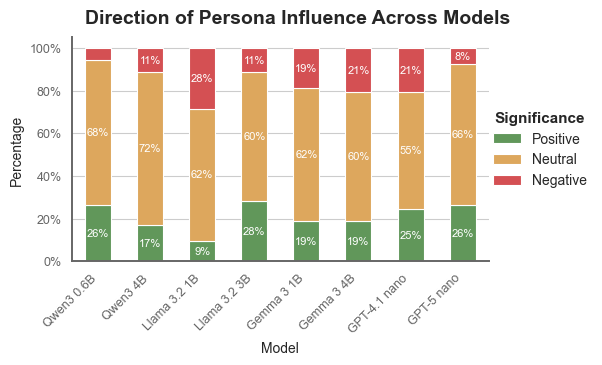

In [11]:
colors = {
    "Positive": "#61975A",
    "Neutral": "#DDA75D",
    "Negative": "#D45053",
}

fig, ax = plt.subplots(figsize=(FULL_WIDTH, 3.5))

ax = bs_model_df.plot(
    kind="bar", stacked=True, ax=ax,
    color=[colors[col] for col in bs_model_df.columns]
)

fig.suptitle("Direction of Persona Influence Across Models")

ax.xaxis.grid(False)
ax.yaxis.set_major_formatter(lambda x, pos: f"{x:.0f}%")
ax.set_ylabel("Percentage")

legend = ax.legend(
    title="Significance",
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False,
)

legend.get_title().set_fontweight("bold")
legend.get_title().set_fontsize(11)

ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

for container in ax.containers:
    labels = [
        f"{bar.get_height():.0f}%" if bar.get_height() > 6 else ""
        for bar in container
    ]

    ax.bar_label(
        container,
        labels=labels,
        label_type="center",
        fontsize=8,
        color="white",
    )

fig.subplots_adjust(
    left=0.11,
    right=0.83,
    top=0.90,
    bottom=0.26,
    wspace=0.20,
)

fig.savefig(plot_path / "02_significance.pdf")
plt.show()

## Per Model Persona Gain

In [12]:
whole_df = df.copy()
whole_df = whole_df.groupby(["Model", "persona", "dataset"], as_index=False).mean(numeric_only=True)

parts = []
for (model_name, dataset_name), group_df in whole_df.groupby(["Model", "dataset"], sort=False):
    if "helpful" in group_df["persona"].unique():
        ref = group_df.loc[group_df["persona"] == "helpful", "Score"]
        ref_score = ref.iloc[0]
    else:
        ref_score = 1 - group_df["Score"].mean()
    group_df["reference_score"] = ref_score
    group_df["Score Improvement"] = group_df["Score"] - ref_score
    parts.append(group_df)

whole_df: pd.DataFrame = pd.concat(parts)
# whole_df = whole_df.sort_values("Model")
whole_df["Model"] = pd.Categorical(whole_df["Model"], categories=model_order, ordered=True)
whole_df = whole_df[whole_df["persona"] != "helpful"]
whole_df = whole_df.sort_values(by=["dataset", "Model"])

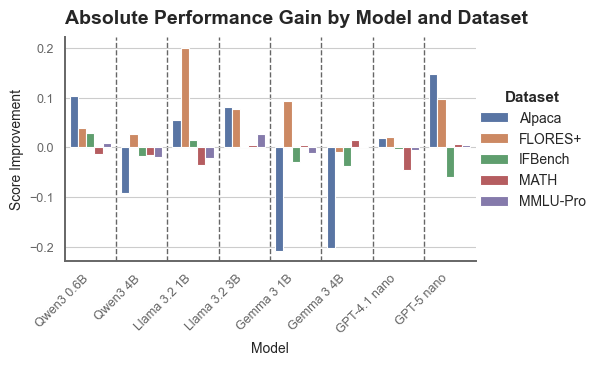

In [13]:
fig, ax = plt.subplots(figsize=(FULL_WIDTH, 3.5))

sns.barplot(whole_df, x="Model", y="Score Improvement", hue="dataset", errorbar=None, ax=ax)

fig.suptitle("Absolute Performance Gain by Model and Dataset")

legend = ax.legend(
    title="Dataset",
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False,
)

legend.get_title().set_fontweight("bold")
legend.get_title().set_fontsize(11)

ax.tick_params(axis="x", rotation=45)
for label in ax.get_xticklabels():
    label.set_ha("right")

fig.subplots_adjust(
    left=0.10,
    right=0.81,
    top=0.90,
    bottom=0.26,
)

x_ticks = np.array(ax.get_xticks())
minor_ticks = (x_ticks[:-1] + x_ticks[1:]) / 2
ax.set_xticks(minor_ticks, minor=True)

ax.grid(
    axis="x",
    which="minor",
    color="0.4",
    linewidth=1.0,
    linestyle="--"
)

fig.savefig(plot_path / "01_gain_per_model.pdf")

## Agreement

In [14]:
def calculate_agreement(
    tests_full_df: pd.DataFrame,    # tests_length_model_df
    tests_const_df: pd.DataFrame,    # tests_length_df
    term: str
) -> pd.DataFrame:
    """Count the number of times a model-agnostic test reaches the same level of significance as a model-dependent one.

    Args:
        tests_full_df (pd.DataFrame): Model-agnostic test results.
        tests_const_df (pd.DataFrame): Results of tests with model-effect interaction term.
        term (str): The name of the dependent variable.

    Returns:
        pd.DataFrame: Results containing model name, total and relative agreement rate, and number of test cases.
    """
    const_df = tests_const_df[tests_const_df["category"].isna()]
    const_df = const_df[const_df["term"] == term]
    full_df = tests_full_df[tests_full_df["term"] == term]

    res = []
    for model_group_name, model_group_df in full_df.groupby("Model"):
        agreement = 0
        for data_name, data_df in model_group_df.groupby("dataset"):
            if "mode" in data_df.columns:
                for mode_name, mode_df in data_df.groupby("mode"):
                    const_sub_df = const_df[(const_df["dataset"] == data_name) & (const_df["mode"] == mode_name)]
                    sig_dataset = const_sub_df.iloc[0]["pvalue"] < 0.05
                    sig_model = mode_df.iloc[0]["pvalue"] < 0.05
                    coef_dataset = const_sub_df.iloc[0]["coef"]
                    coef_model = mode_df.iloc[0]["coef"]
                    if sig_dataset and sig_model and ((coef_dataset < 0 and coef_model < 0) or (coef_dataset > 0 and coef_model > 0)):
                        agreement += 1
                    elif not sig_dataset and not sig_model:
                        agreement += 1
            else:
                const_sub_df = const_df[const_df["dataset"] == data_name]
                sig_dataset = const_sub_df.iloc[0]["pvalue"] < 0.05
                sig_model = data_df.iloc[0]["pvalue"] < 0.05
                coef_dataset = const_sub_df.iloc[0]["coef"]
                coef_model = data_df.iloc[0]["coef"]
                if sig_dataset and sig_model and ((coef_dataset < 0 and coef_model < 0) or (coef_dataset > 0 and coef_model > 0)):
                    agreement += 1
                elif not sig_dataset and not sig_model:
                    agreement += 1
        res.append((
            model_group_name, agreement / len(const_df),
            agreement, len(const_df)
        ))
    return pd.DataFrame(
        res,
        columns=["Model", "rel_agreement", "tot_agreement", "cases"]
    )

### Length

In [15]:
length_lr_df = test_dfs["length_model_lr"]
length_lr_df[length_lr_df["pvalue"] < 0.05]

,dataset,category,lr_stat,diff,pvalue,mode
0,mmlu-pro,NaN,55.902398,7.0,9.874614e-10,static
1,mmlu-pro,NaN,56.690946,7.0,6.885718e-10,dynamic
2,mmlu-pro,NaN,65.356471,7.0,1.275100e-11,combined
3,alpaca,NaN,137.758599,7.0,1.498177e-26,static
4,alpaca,NaN,139.616480,7.0,6.115938e-27,dynamic
5,alpaca,NaN,62.033282,7.0,5.919827e-11,combined
8,MATH,NaN,14.237561,7.0,4.711387e-02,combined
12,flores,NaN,64.333729,7.0,2.046633e-11,static
14,flores,NaN,38.275251,7.0,2.686055e-06,combined


In [16]:
length_model_df = test_dfs["length_model"]
length_df = test_dfs["length"]

length_agreement = calculate_agreement(length_model_df, length_df, "length")
length_agreement

,Model,rel_agreement,tot_agreement,cases
0,gemma-3-1b-it,0.600000,9,15
1,gemma-3-4b-it,0.466667,7,15
2,gpt-4-1-nano,0.866667,13,15
3,gpt-5-nano,0.600000,9,15
4,llama-3-2-1b-instruct,0.400000,6,15
5,llama-3-2-3b-instruct,0.600000,9,15
6,qwen3-0-6b,0.600000,9,15
7,qwen3-4b,0.600000,9,15


### Teacher

In [17]:
teacher_lr_df = test_dfs["teacher_model_lr"]
teacher_lr_df[teacher_lr_df["pvalue"] < 0.05]

,dataset,category,lr_stat,diff,pvalue
0,mmlu-pro,NaN,37.98841,7.0,3.045585e-06
1,alpaca,NaN,142.15639,7.0,1.795656e-27
4,flores,NaN,421.49349,7.0,5.845684e-87


In [18]:
teacher_model_df = test_dfs["teacher_model"]
teacher_df = test_dfs["teacher"]

teacher_agreement = calculate_agreement(teacher_model_df, teacher_df, "level")
teacher_agreement

,Model,rel_agreement,tot_agreement,cases
0,gemma-3-1b-it,0.6,3,5
1,gemma-3-4b-it,0.8,4,5
2,gpt-4-1-nano,0.8,4,5
3,gpt-5-nano,0.8,4,5
4,llama-3-2-1b-instruct,0.8,4,5
5,llama-3-2-3b-instruct,0.8,4,5
6,qwen3-0-6b,0.8,4,5
7,qwen3-4b,0.6,3,5


### Stat. vs. Dyn.

In [19]:
dynamic_lr_df = test_dfs["static_vs_dynamic_model_lr"]
dynamic_lr_df[dynamic_lr_df["pvalue"] < 0.05]

,dataset,category,lr_stat,diff,pvalue
0,mmlu-pro,NaN,87.608313,7.0,3.830228e-16
1,alpaca,NaN,746.228681,7.0,7.403572e-157
4,flores,NaN,43.836394,7.0,2.298753e-07


In [20]:
dynamic_model_df = test_dfs["static_vs_dynamic_model"]
dynamic_df = test_dfs["static_vs_dynamic"]

dynamic_agreement = calculate_agreement(dynamic_model_df, dynamic_df, "is_dynamic")
dynamic_agreement

,Model,rel_agreement,tot_agreement,cases
0,gemma-3-1b-it,1.0,5,5
1,gemma-3-4b-it,1.0,5,5
2,gpt-4-1-nano,0.8,4,5
3,gpt-5-nano,1.0,5,5
4,llama-3-2-1b-instruct,1.0,5,5
5,llama-3-2-3b-instruct,0.8,4,5
6,qwen3-0-6b,0.8,4,5
7,qwen3-4b,0.8,4,5


### Total

In [21]:
total_agreement = pd.concat([length_agreement, teacher_agreement, dynamic_agreement])
total_agreement = total_agreement.groupby("Model", as_index=False).agg(total_agreement=("tot_agreement", "sum"), total_cases=("cases", "sum"))
total_agreement["agreement_ratio"] = total_agreement["total_agreement"] / total_agreement["total_cases"]
total_agreement

,Model,total_agreement,total_cases,agreement_ratio
0,gemma-3-1b-it,17,25,0.68
1,gemma-3-4b-it,16,25,0.64
2,gpt-4-1-nano,21,25,0.84
3,gpt-5-nano,18,25,0.72
4,llama-3-2-1b-instruct,15,25,0.60
5,llama-3-2-3b-instruct,17,25,0.68
6,qwen3-0-6b,17,25,0.68
7,qwen3-4b,16,25,0.64


## Direction Change

In [22]:
from collections import defaultdict

results = []
for full_test_df, const_test_df, coef_term in [
    (length_model_df, length_df, "length"),
    (dynamic_model_df, dynamic_df, "is_dynamic"),
    (teacher_model_df, teacher_df, "level")
]:
    tl_df = const_test_df[const_test_df["category"].isna()]
    tl_df = tl_df[tl_df["term"] == coef_term]
    tlm_df = full_test_df[full_test_df["term"] == coef_term]
    for model_name, group_df in tlm_df.groupby("Model"):
        model_results = defaultdict(int)
        model_results["Model"] = model_name
        model_results["type"] = coef_term
        for dataset_name, dataset_df in group_df.groupby("dataset"):
            if "mode" in dataset_df.columns:
                for mode, mode_group_df in dataset_df.groupby("mode"):
                    sub_df = tl_df[(tl_df["dataset"] == dataset_name) & (tl_df["mode"] == mode)]
                    sig_main = sub_df.iloc[0]["pvalue"] < 0.05
                    sig_mod = mode_group_df.iloc[0]["pvalue"] < 0.05
                    coef_data = sub_df.iloc[0]["coef"]
                    coef_mod = mode_group_df.iloc[0]["coef"]
                    if sig_main and sig_mod:
                        if coef_data < 0 and coef_mod < 0:
                            model_results["same"] += 1
                        elif coef_data > 0 and coef_mod > 0:
                            model_results["same"] += 1
                        elif coef_data < 0 < coef_mod:
                            model_results["neg_to_pos"] += 1
                        elif coef_data > 0 > coef_mod:
                            model_results["pos_to_neg"] += 1
                    elif sig_main:
                        if coef_data < 0 and coef_mod < 0:
                            model_results["neg_to_net"] += 1
                        elif coef_data > 0 and coef_mod > 0:
                            model_results["pos_to_net"] += 1
                        elif coef_data < 0 < coef_mod:
                            model_results["neg_to_net"] += 1
                        elif coef_data > 0 > coef_mod:
                            model_results["pos_to_net"] += 1
                    elif sig_mod:
                        if coef_data < 0 and coef_mod < 0:
                            model_results["net_to_neg"] += 1
                        elif coef_data > 0 and coef_mod > 0:
                            model_results["net_to_pos"] += 1
                        elif coef_data < 0 < coef_mod:
                            model_results["net_to_pos"] += 1
                        elif coef_data > 0 > coef_mod:
                            model_results["net_to_pos"] += 1
                    else:
                        model_results["same"] += 1
            else:
                sub_df = tl_df[tl_df["dataset"] == dataset_name]
                sig_main = sub_df.iloc[0]["pvalue"] < 0.05
                sig_mod = dataset_df.iloc[0]["pvalue"] < 0.05
                coef_data = sub_df.iloc[0]["coef"]
                coef_mod = dataset_df.iloc[0]["coef"]
                if sig_main and sig_mod:
                    if coef_data < 0 and coef_mod < 0:
                        model_results["same"] += 1
                    elif coef_data > 0 and coef_mod > 0:
                        model_results["same"] += 1
                    elif coef_data < 0 < coef_mod:
                        model_results["neg_to_pos"] += 1
                    elif coef_data > 0 > coef_mod:
                        model_results["pos_to_neg"] += 1
                elif sig_main:
                    if coef_data < 0 and coef_mod < 0:
                        model_results["neg_to_net"] += 1
                    elif coef_data > 0 and coef_mod > 0:
                        model_results["pos_to_net"] += 1
                    elif coef_data < 0 < coef_mod:
                        model_results["neg_to_net"] += 1
                    elif coef_data > 0 > coef_mod:
                        model_results["pos_to_net"] += 1
                elif sig_mod:
                    if coef_data < 0 and coef_mod < 0:
                        model_results["net_to_neg"] += 1
                    elif coef_data > 0 and coef_mod > 0:
                        model_results["net_to_pos"] += 1
                    elif coef_data < 0 < coef_mod:
                        model_results["net_to_pos"] += 1
                    elif coef_data > 0 > coef_mod:
                        model_results["net_to_pos"] += 1
                else:
                    model_results["same"] += 1
        results.append(model_results)
results_df = pd.DataFrame(results)
results_df = results_df.fillna(0)
results_df = results_df.groupby("Model", as_index=False).sum(numeric_only=True)
results_df

,Model,same,pos_to_net,neg_to_net,net_to_pos,pos_to_neg,neg_to_pos
0,gemma-3-1b-it,17,5.0,2.0,1.0,0.0,0.0
1,gemma-3-4b-it,16,4.0,0.0,3.0,2.0,0.0
2,gpt-4-1-nano,21,1.0,2.0,1.0,0.0,0.0
3,gpt-5-nano,18,4.0,2.0,0.0,0.0,1.0
4,llama-3-2-1b-instruct,15,5.0,3.0,0.0,2.0,0.0
5,llama-3-2-3b-instruct,17,4.0,2.0,1.0,0.0,1.0
6,qwen3-0-6b,17,4.0,3.0,1.0,0.0,0.0
7,qwen3-4b,16,3.0,3.0,1.0,1.0,0.0


# Model Size

In [23]:
model_size_df = df.copy()
# model_size_df = model_size_df[~model_size_df["Model"].isin(["GPT 5 Nano", "GPT 4.1 Nano"])]
model_size_df.loc[model_size_df["Model"].isin(["Qwen3 0.6B", "Gemma 3 1B", "Llama 3.2 1B"]), "Size"] = 0
model_size_df.loc[model_size_df["Model"].isin(["Qwen3 4B", "Gemma 3 4B", "Llama 3.2 3B"]), "Size"] = 1
model_size_df.loc[model_size_df["Model"].isin(["GPT-4.1 nano", "GPT-5 nano"]), "Size"] = 2

category_mapping = {0: "Small", 1: "Medium", 2: "Large"}
model_size_df["Size"] = model_size_df["Size"].map(category_mapping)
model_size_df["Size"] = pd.Categorical(model_size_df["Size"], list(category_mapping.values()), ordered=True)

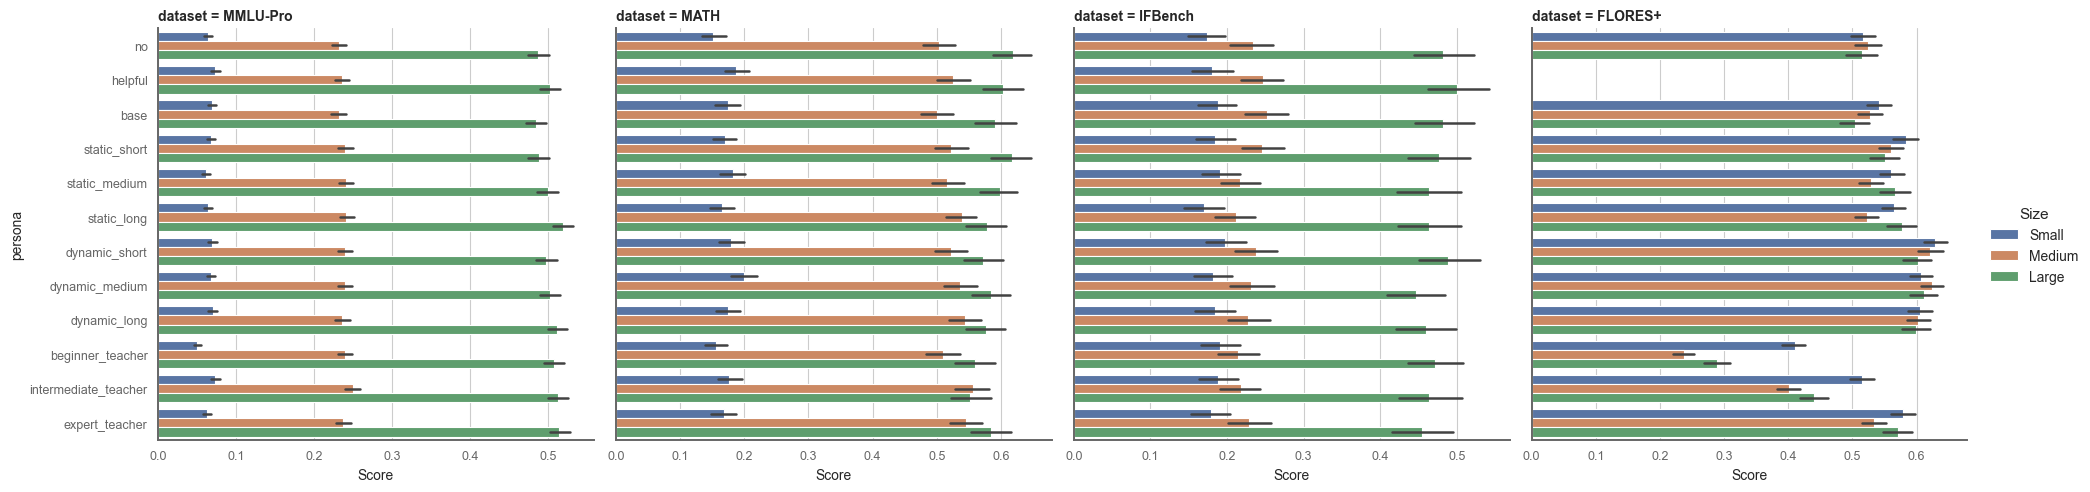

In [24]:
base_vis_df = model_size_df[~model_size_df["dataset"].isin(["Alpaca", "Flores"])]
sns.catplot(base_vis_df, col="dataset", y="persona", kind="bar", x="Score", orient="h", sharex=False, hue="Size")

## Length


In [25]:
from evaluate import prepare_length

dfs = []
for mode in ["static", "dynamic", "combined"]:
    mode: Literal["static", "dynamic", "combined"] = mode  # to silence warning
    length_df = prepare_length(model_size_df, mode)
    length_df["Mode"] = mode.capitalize()
    dfs.append(length_df)
length_df: pd.DataFrame = pd.concat(dfs)
length_mapping = {1: "base", 2: "short", 3: "medium", 4: "long"}
length_df["Persona Length"] = length_df["length"].map(length_mapping)
length_df["Persona Length"] = pd.Categorical(length_df["Persona Length"], categories=list(length_mapping.values()), ordered=True)

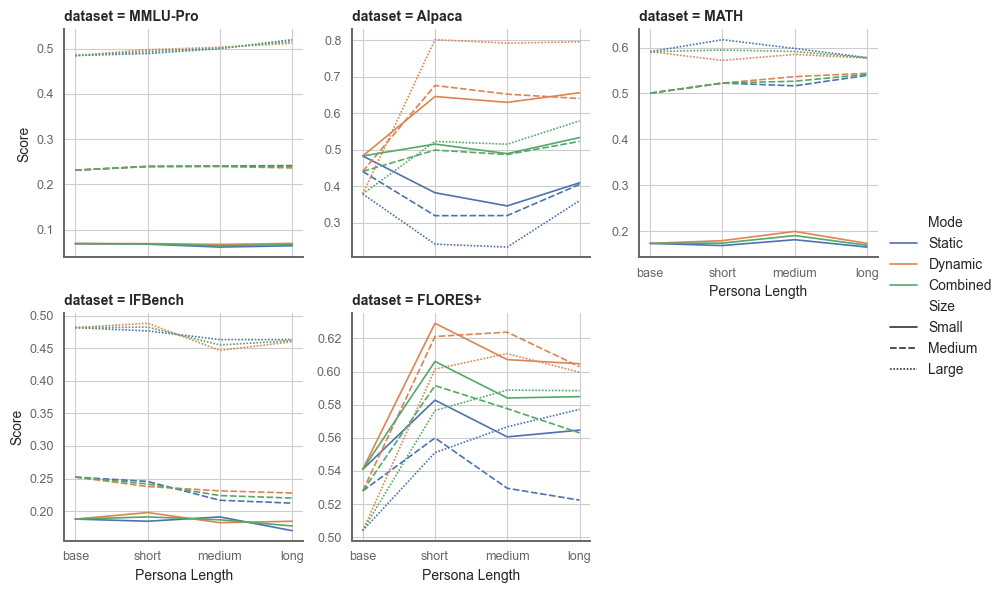

In [26]:
facet_kw = {"sharey": False}
sns.relplot(
    length_df, x="Persona Length", y="Score", col="dataset", hue="Mode", style="Size", kind="line",
    height=3, col_wrap=3, err_style=None, facet_kws=facet_kw
)

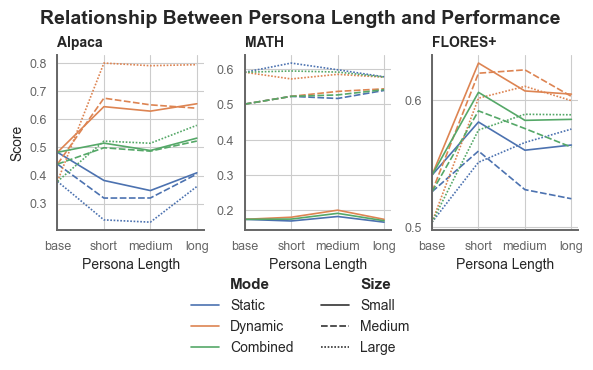

In [27]:
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

length_vis_df = length_df[~length_df["dataset"].isin(["IFBench", "MMLU-Pro"])]

n_cols = length_vis_df["dataset"].nunique()
aspect = FULL_WIDTH / (3.5 * n_cols)

facet_kw = {
    **facet_kw,
    "legend_out": False,
}
g = sns.relplot(
    length_vis_df, x="Persona Length", y="Score", col="dataset", hue="Mode", style="Size", kind="line",
    facet_kws=facet_kw, err_style=None, height=3.5, aspect=aspect,
)

g.figure.suptitle("Relationship Between Persona Length and Performance")

g.set_titles("{col_name}")

g.figure.set_size_inches(FULL_WIDTH, 3.5)

g.figure.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.85,
    bottom=0.35,
    wspace=0.28,
)

sns.move_legend(
    g,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.25),
    bbox_transform=g.figure.transFigure,
    ncol=2,
    frameon=False,
)

main_legend = g.legend
if main_legend is not None:
    for text in main_legend.get_texts():
        if text.get_text() in ["Mode", "Size"]:
            text.set_fontweight("bold")
            text.set_fontsize(11)

for idx, ax in enumerate(g.axes.flat):
    ax.set_xlim(left=0)
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

g.figure.savefig(plot_path / "06_model_size_length.pdf")

## Teacher Expertise

In [28]:
from evaluate import prepare_teacher

teacher_df = prepare_teacher(model_size_df)
teacher_mapping = {0: "beginner", 1: "intermediate", 2: "expert"}
teacher_df["Audience Level"] = teacher_df["level"].map(teacher_mapping)
teacher_df["Audience Level"] = pd.Categorical(teacher_df["Audience Level"], categories=list(teacher_mapping.values()), ordered=True)

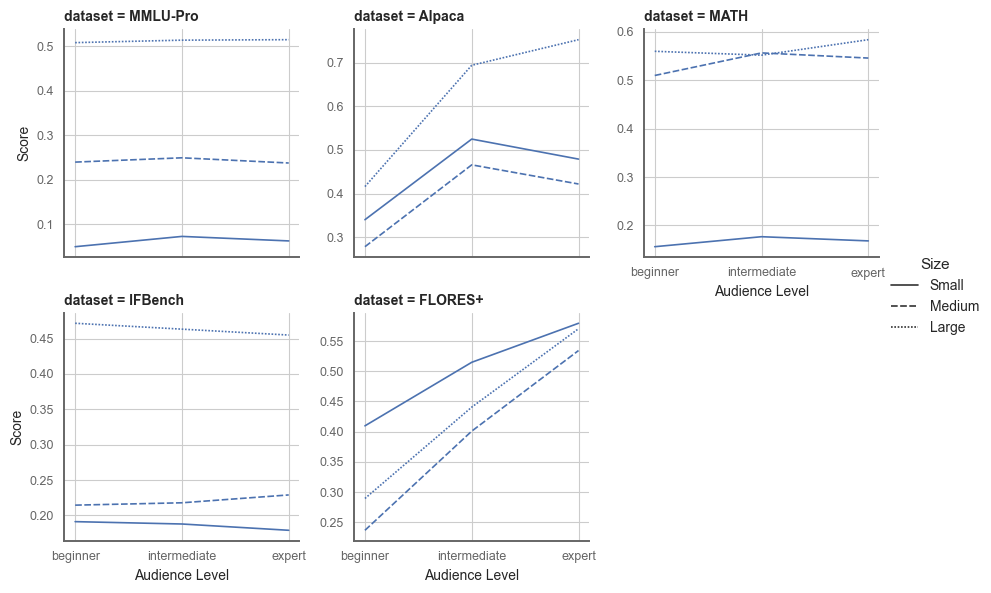

In [29]:
facet_kw = {"sharey": False}
sns.relplot(teacher_df, x="Audience Level", y="Score", col="dataset", style="Size", kind="line", col_wrap=3, facet_kws=facet_kw,
            height=3, err_style=None)

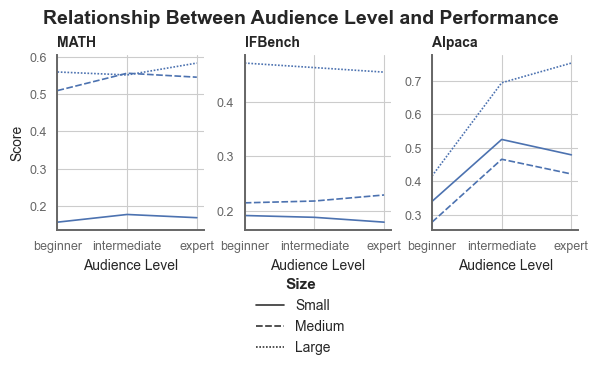

In [30]:
teacher_vis_df = teacher_df[teacher_df["dataset"].isin(["IFBench", "Alpaca", "MATH"])]
teacher_vis_df = teacher_vis_df.sort_values(by="Size")

FIG_HEIGHT = 3.5

n_cols = length_vis_df["dataset"].nunique()
aspect = FULL_WIDTH / (FIG_HEIGHT * n_cols)

g = sns.relplot(
    teacher_vis_df, x="Audience Level", y="Score", col="dataset", style="Size", kind="line",
    facet_kws=facet_kw, height=FIG_HEIGHT, aspect=aspect, err_style=None
)

g.figure.suptitle("Relationship Between Audience Level and Performance")
g.set_titles("{col_name}")

main_legend = g.legend
if main_legend is not None:
    legend_title = main_legend.get_title()
    legend_title.set_fontweight("bold")
    legend_title.set_fontsize(11)

sns.move_legend(
    g,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.25),
    bbox_transform=g.figure.transFigure,
    frameon=False,
)

g.figure.subplots_adjust(
    left=0.08,
    right=0.98,
    top=0.85,
    bottom=0.35,
    wspace=0.28,
)

for idx, ax in enumerate(g.axes.flat):
    ax.set_xlim(left=0)
    ax.yaxis.set_major_locator(MultipleLocator(0.1))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.1f"))

g.figure.set_size_inches(FULL_WIDTH, FIG_HEIGHT)
g.figure.savefig(plot_path / "06_model_size_teacher.pdf")

## Static vs. dynamic

In [31]:
from evaluate import prepare_static_vs_dynamic

dynamic_df = prepare_static_vs_dynamic(model_size_df)
dynamic_df.reset_index(inplace=True)
dynamic_df = dynamic_df.rename(columns={"is_dynamic": "Persona Type"})
dynamic_df["Persona Type"] = dynamic_df["Persona Type"].replace({0: "Static", 1: "Dynamic"})

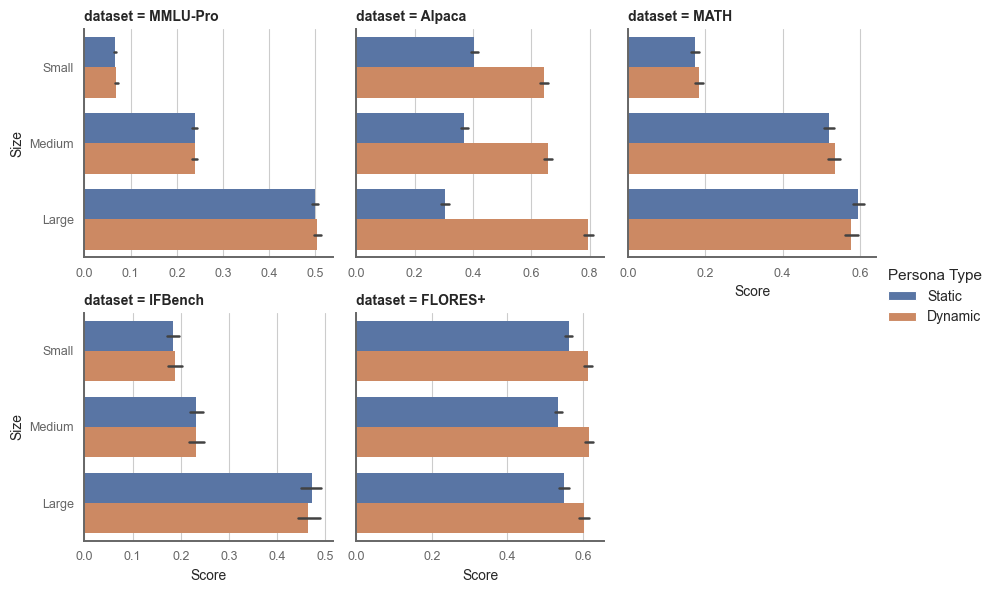

In [32]:
sns.catplot(
    dynamic_df, col="dataset", x="Score", hue="Persona Type", y="Size", kind="bar", orient="h", col_wrap=3,
    sharex=False, height=3, linestyle="none"
)

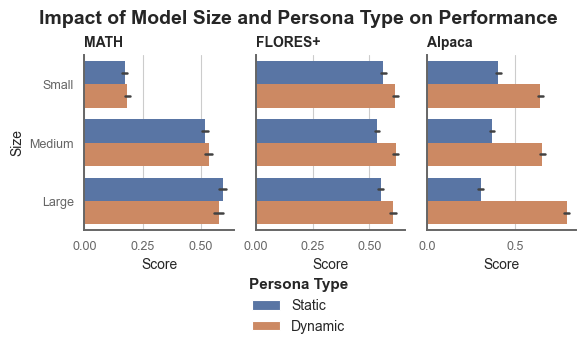

In [33]:
dynamic_vis_df = dynamic_df[dynamic_df["dataset"].isin(["Alpaca", "FLORES+", "MATH"])]
dynamic_vis_df = dynamic_vis_df.sort_values(by="Size")

FIG_HEIGHT = 3.5

n_cols = length_vis_df["dataset"].nunique()
aspect = FULL_WIDTH / (FIG_HEIGHT * n_cols)

g = sns.catplot(
    dynamic_vis_df, col="dataset", x="Score", hue="Persona Type", y="Size", kind="bar", orient="h", col_wrap=3,
    sharex=False, linestyle="none", height=FIG_HEIGHT, aspect=aspect
)

g.figure.suptitle("Impact of Model Size and Persona Type on Performance")

g.set_titles("{col_name}")

sns.move_legend(
    g,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.25),
    bbox_transform=g.figure.transFigure,
    frameon=False,
)

g.figure.subplots_adjust(
    left=0.13,
    right=0.98,
    top=0.85,
    bottom=0.35,
    wspace=0.15,
)

main_legend = g.legend
if main_legend is not None:
    legend_title = main_legend.get_title()
    legend_title.set_fontweight("bold")
    legend_title.set_fontsize(11)

g.figure.set_size_inches(FULL_WIDTH, FIG_HEIGHT)
g.figure.savefig(plot_path / "06_model_size_dynamic.pdf")

# Helpful Assistant vs. No Persona

In [34]:
helpful_df = df[df["persona"].isin(["no", "helpful"])].copy()
helpful_df.loc[:, "Persona"] = helpful_df["persona"].str.capitalize()
helpful_df = helpful_df[helpful_df["dataset"].isin(["MMLU-Pro", "MATH", "IFBench"])]

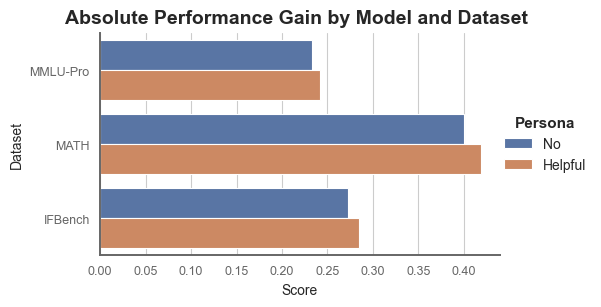

In [35]:
fig, ax = plt.subplots(figsize=(FULL_WIDTH, 3))

sns.barplot(helpful_df, x="Score", y="dataset", hue="Persona", errorbar=None, ax=ax)

fig.suptitle("Absolute Performance Gain by Model and Dataset")

legend = ax.legend(
    title="Persona",
    loc="center left",
    bbox_to_anchor=(0.98, 0.5),
    frameon=False,
)

ax.set_ylabel("Dataset")

legend.get_title().set_fontweight("bold")
legend.get_title().set_fontsize(11)

fig.subplots_adjust(
    left=0.16,
    right=0.85,
    top=0.90,
    bottom=0.16,
)

fig.savefig(plot_path / "05_helpful_vs_no.pdf")